# Week 4 - Probability Distributions 3 and Mixture Models

Learning contents:

1. Histogram-based density estimation
    - Display histogram densities
2. Kernel density estimation
    - Hypercube Kernel function
    - Gaussian Kernel function
3. K-Nearest Neigbours classification
    - Generate data
    - Classification function
    - Display results
4. K-Means clustering
    - Display results

## Dependencies

In [69]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from math import sqrt
from collections import Counter
from scipy.stats import norm
from sklearn import datasets
from IPython.display import HTML
from math import floor

import seaborn as sns; sns.set(); sns.set_palette('bright')

## Generate data

write a function `generate_data_1D` that returns `n` realizations of a single random variable exhibiting mixture of Gaussian distribution with parameters `means`, `variances` and `pi`.

In [70]:
def generate_data_1D(size, means, variances, pi):
    x=[]
    np.random.seed(10)
    for i in range(size):
        z_i = np.argmax(np.random.multinomial(1, pi))
        x_i = np.random.normal(means[z_i], variances[z_i]) 
        x.append(x_i)
    return x

The function below generates 1000 data points from the Gaussian mixture distribution and plots their histogram. Observe the plot and comment on whether the plot coincides with the input data.

(array([0.03759899, 0.0150396 , 0.0075198 , 0.0150396 , 0.03759899,
        0.03007919, 0.02255939, 0.03759899, 0.06767818, 0.04511879,
        0.14287615, 0.08271777, 0.10527717, 0.10527717, 0.15791575,
        0.21055433, 0.22559393, 0.14287615, 0.21055433, 0.10527717,
        0.15791575, 0.16543555, 0.12783656, 0.11279696, 0.13535636,
        0.06767818, 0.06767818, 0.06767818, 0.03007919, 0.03759899,
        0.05263858, 0.05263858, 0.03759899, 0.04511879, 0.03007919,
        0.03007919, 0.05263858, 0.04511879, 0.03007919, 0.0150396 ,
        0.05263858, 0.0150396 , 0.05263858, 0.04511879, 0.07519798,
        0.06767818, 0.09775737, 0.09775737, 0.07519798, 0.09775737,
        0.04511879, 0.06767818, 0.06767818, 0.04511879, 0.03759899,
        0.07519798, 0.06767818, 0.04511879, 0.0075198 , 0.02255939,
        0.0075198 , 0.0075198 , 0.04511879, 0.02255939, 0.06015838,
        0.06767818, 0.06767818, 0.06767818, 0.06015838, 0.10527717,
        0.11279696, 0.11279696, 0.13535636, 0.09

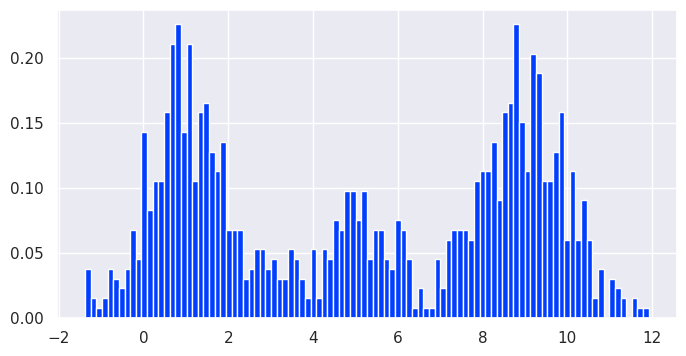

In [71]:
means = [1, 5, 9]
variances = [1, 1, 1]
pis = [0.4, 0.2, 0.4]
data = generate_data_1D(1000, means, variances, pis)
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(data, bins=100, density=True)

## 1) Histogram-based density estimation

write a function `histogram` that takes input `data`, user-defined bin size `delta` and returns `bins` (list of edges of the bins) and their corresponding `probabilities`. Hint: you can use numpy's histogram function to do so.

In [72]:
def histogram(data, delta):
    no_bins = floor((max(data) - min(data)) / delta)
    probs, bins = np.histogram(data, no_bins, density=True)
    return bins, probs

### 1.1) Display histogram densities

Display the `histograms` for different values of bin sizes and also compute and plot the `true` probability density (slide 9 of lecture 7) of the data. Compare the two plots and see which values of bin sizes reveal densities that are close to the true density function

In [73]:
def univariate_normal(x, mean, variance):
    return ((1. / np.sqrt(2 * np.pi * variance)) * np.exp(-(x - mean)**2 / (2 * variance)))

def display_histogram_density(data, delta):
    bins, probs = histogram(data, delta)

    a = np.arange(-5, 15, 0.01)
    y = pis[0] * univariate_normal(a, mean=means[0], variance=variances[0]**2) + pis[1] * univariate_normal(a, mean=means[1], variance=variances[1]**2)+ pis[2] * univariate_normal(a, mean=means[2], variance=variances[2]**2)
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar(bins[:-1],probs,width=0.1)
    ax.plot(a, y,'-r')

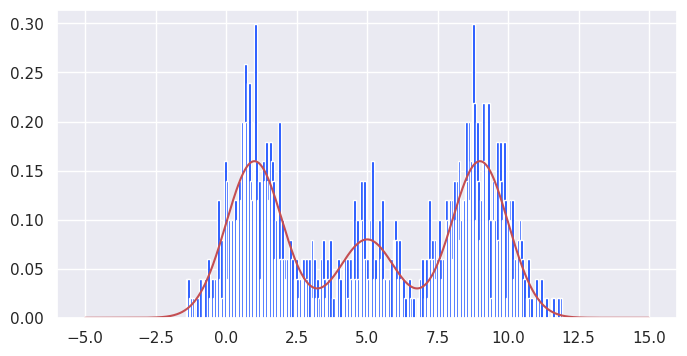

In [74]:
display_histogram_density(data, 0.05)

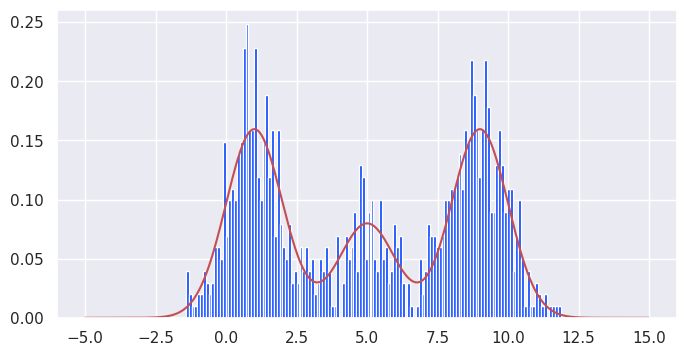

In [75]:
display_histogram_density(data, 0.1)

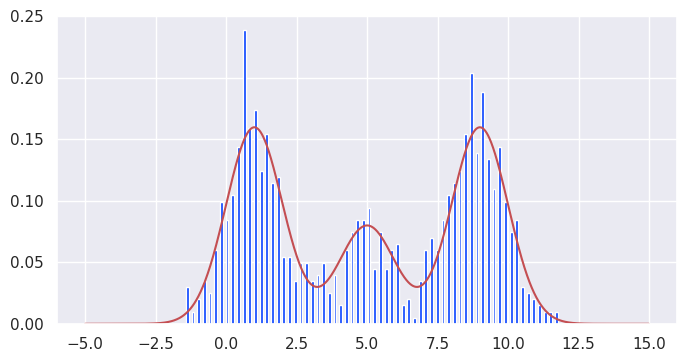

In [76]:
display_histogram_density(data, 0.2)

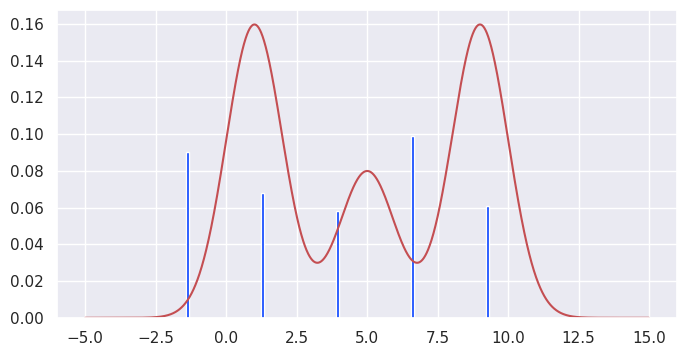

In [77]:
display_histogram_density(data, 2.5)

## 2) Kernel density estimation

### 2.1) Hypercube Kernel function

write a function `hypercube_kernel_function` takes `u` and returns 0 or 1 if `u` is inside 1/2 hypercube (see slide 18 of lecture 7).

In [78]:
def hypercube_kernel_function(u):
    if type(u) is not np.ndarray:
        return 1 if abs(u) <= 0.5 else 0
    for ui in u:
        if abs(ui) <= 0.5:
            return 1
    return 0

write the function `hypercube_kernel_density` that takes a single data point `x`, training data points `data`, size of a cube `h`, data dimensions `D` and returns the probability density of `x` based on the Hypercube kernel function (see the first equation on slide 19 of lecture 7)

In [79]:
def hypercube_kernel_density(x, data, h, D):
    N = len(data)
    sumpart = 0
    for xn in data:
        sumpart += (1/(h**D)) * hypercube_kernel_function((x - xn) / h)
    return (1/N) * sumpart

display the computed nonparametric density estimates for different values of `h`. What is the effect of `h` on density estimates?

In [80]:
def display_hypercube_kernel_density_1D(data, h, color='b'):
    xs = np.linspace(min(data), max(data), 200)
    plt.plot(xs, list(map(lambda x: hypercube_kernel_density(x, data, h, 1), xs)), '-' + color, label='h=' + str(h))
    plt.legend()

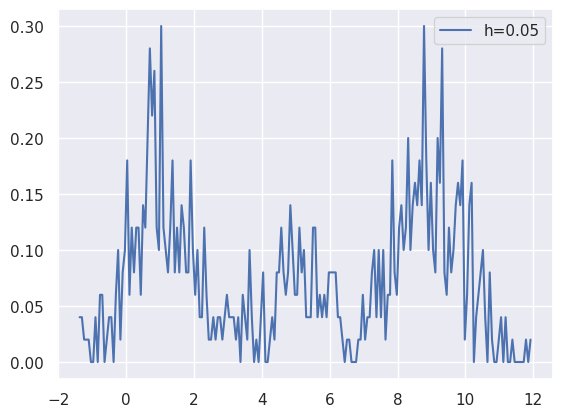

In [81]:
display_hypercube_kernel_density_1D(data, 0.05, 'b')

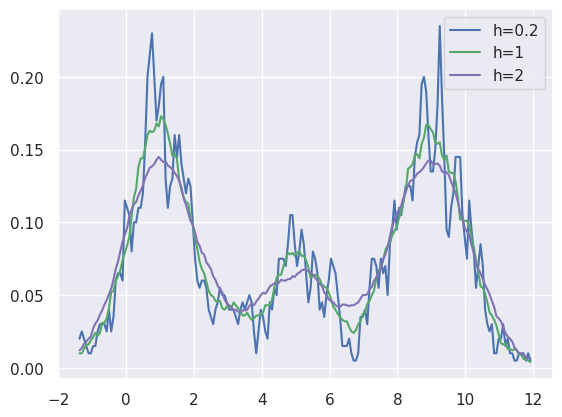

In [82]:
display_hypercube_kernel_density_1D(data, 0.2, 'b')
display_hypercube_kernel_density_1D(data, 1, 'g')
display_hypercube_kernel_density_1D(data, 2, 'm')

The density estimates get noisier with smaller values of h and smoother with larger values of h. The problem with smoother estimates is that it then "ignores" more of the data.

### 2.2) Gaussian Kernel function

Write the function `gaussian_kernel_function` that takes pair of points `x` and `x_n`, size `h` and returns Gaussian kernel function value for the pair of points.

In [83]:
def gaussian_kernel_function(x, x_n, h):
    return 1/sqrt(2 * np.pi * h**2) * np.exp(- (np.abs(x - x_n)**2) / (2*h**2))


Write the `gaussian_kernel_density` function that takes any point `x`, training data points `data`, size `h` and returns the Gaussian kernel density value for the point `x` (see the last equation in slide 19 of lecture 7)

In [84]:
def gaussian_kernel_density(x, data, h):
    N = len(data)
    sumpart = 0
    for xn in data:
        sumpart += gaussian_kernel_function(x, xn, h)
    return (1/N) * sumpart

In [85]:
def display_gaussian_kernel_density_1D(data, h, color='b'):
    xs = np.linspace(min(data), max(data), 200)
    plt.plot(xs, list(map(lambda x: gaussian_kernel_density(x, data, h), xs)), '-' + color, label='h=' + str(h))
    plt.legend()

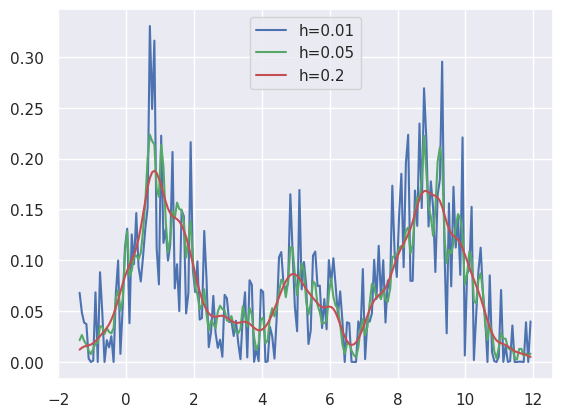

In [86]:
display_gaussian_kernel_density_1D(data, 0.01, 'b')
display_gaussian_kernel_density_1D(data, 0.05, 'g')
display_gaussian_kernel_density_1D(data, 0.2, 'r')

## 3) K-Nearest Neigbours classification

### 3.1) Generate Data

Using IRIS dataset from the sklearn library. Note that the data is 2-dimensional (two features). The data can belong to one of the 3 classes as shown in the following figure with different colors. The following code plots the data and corresponding targets (classes).

(<matplotlib.collections.PathCollection at 0x76b4608ff070>,
 <matplotlib.legend.Legend at 0x76b4608ff280>)

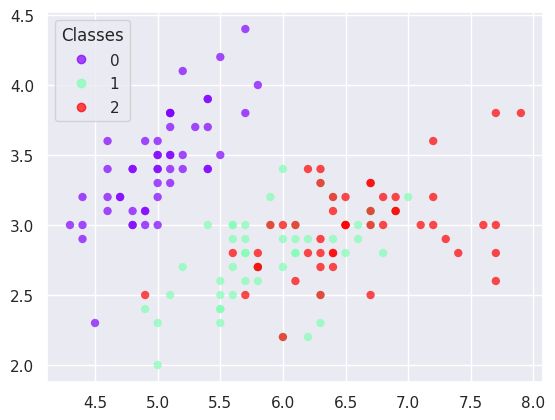

In [87]:
iris = datasets.load_iris()
iris_x = np.array(iris.data[:, :2])  # we only take the first two features.
iris_t = np.array(iris.target)

def plot_iris(legend=True, classes=iris_t, target=plt):
    scatter = target.scatter(iris_x[:, 0], iris_x[:, 1], c=classes, alpha=0.7, cmap='rainbow', edgecolor='none')
    if legend:
        legend = target.legend(*scatter.legend_elements(), loc="upper left", title="Classes")
        return (scatter, legend)
    return (scatter, )

plot_iris()

### 3.2) Classification function

write the `k_nearest_classification` function that takes a test data point `x`, training data points `data_x` and their associated classes `data_t`, the neighbours `k` and returns the predicted class for the test point `x`

In [88]:
def k_nearest_classification(x, data_x, data_t, k):
    distance = np.linalg.norm(data_x - x, axis=1)
    sorted_indices = np.argsort(distance)[:k]
    sorted_classes = data_t[sorted_indices]
    return Counter(sorted_classes).most_common(1)[0][0]

### 3.3) Display results

Display the classification results for different values of `K`

In [89]:
def plot_mesh(pred_fn, n_class=3, x_min=4, x_max=8, y_min=2, y_max=4.5, target=plt):
    h = 0.1  # step size in the mesh
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    Z = np.array(list(map(lambda x: pred_fn(np.array(x)), np.c_[xx.ravel(), yy.ravel()])))
    Z = Z.reshape(xx.shape)
    cs = target.contourf(xx, yy, Z, alpha = 0.1, cmap=plt.cm.get_cmap('rainbow', n_class))
    target.axis('tight')
    if hasattr(target, 'xlim'):
        target.xlim(x_min, x_max)
        target.ylim(y_min, y_max)

/tmp/ipykernel_14546/3786169586.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cs = target.contourf(xx, yy, Z, alpha = 0.1, cmap=plt.cm.get_cmap('rainbow', n_class))


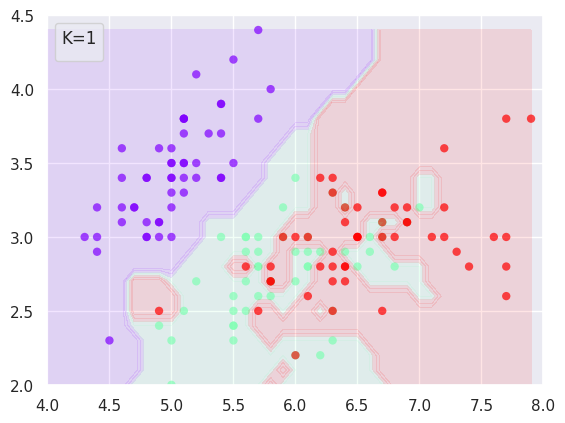

In [90]:
plot_iris(False)
plot_mesh(lambda x: k_nearest_classification(x, iris_x, iris_t, 1))
plt.legend([], loc="upper left", title="K=1")

/tmp/ipykernel_14546/3786169586.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cs = target.contourf(xx, yy, Z, alpha = 0.1, cmap=plt.cm.get_cmap('rainbow', n_class))


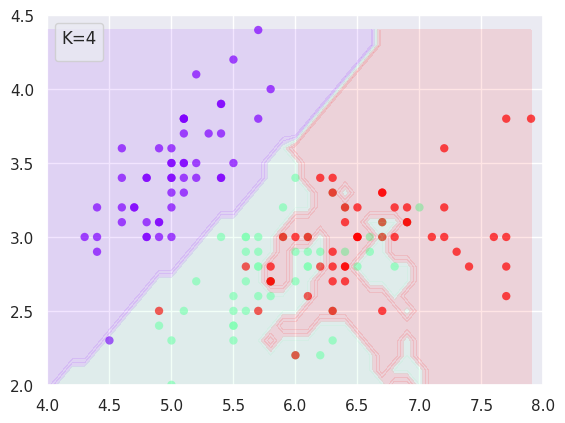

In [91]:
plot_iris(False)
plot_mesh(lambda x: k_nearest_classification(x, iris_x, iris_t, 4))
plt.legend([], loc="upper left", title="K=4")

/tmp/ipykernel_14546/3786169586.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cs = target.contourf(xx, yy, Z, alpha = 0.1, cmap=plt.cm.get_cmap('rainbow', n_class))


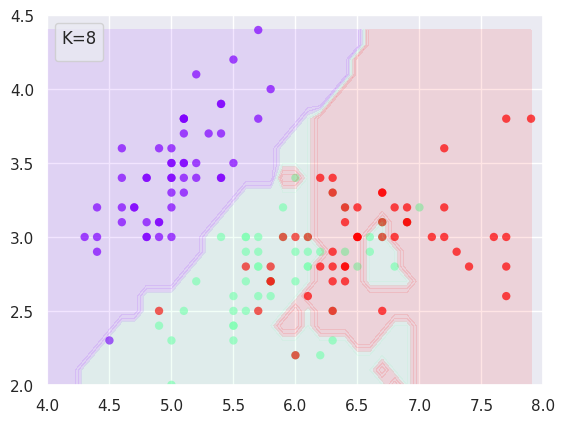

In [92]:
plot_iris(False)
plot_mesh(lambda x: k_nearest_classification(x, iris_x, iris_t, 8))
plt.legend([], loc="upper left", title="K=8")

## 4) K-Means clustering

write the `k_means_step` function that takes initial means vector `mus_0`, input data points `data_x` and returns the new means `mus` and `classes` after running a SINGLE ITERATION of the K-means algorithm

Write a function k_means_step(mus_0, data_x) that performs one iteration of the K-means algorithm:

    Assign each data point in data_x to the closest mean in mus_0.

    Compute the new cluster means as the average of the points assigned to each cluster.

    Return the updated means mus and the cluster assignments classes.

In [93]:
def k_means_step(mus_0, data_x):
    N = len(data_x)
    K = len(mus_0)
    
    r = np.zeros((N, K))
    mus = mus_0.copy()*0
    classes = np.zeros(N)
    distance = np.zeros((N, K))
    
    for k in range(K):
        distance[:, k] = np.linalg.norm(data_x - mus_0[k], axis=1)
    
    for n in range(N):
        k = np.argmin(distance[n])
        r[n,k] = 1
        classes[n] = k
        mus[k] += r[n,k] * data_x[n]
        
    for k in range(K):
        mus[k] = mus[k] / np.sum(r[:,k])

    return mus, classes

Write a function distortion_measure(mus, classes, data_x) that computes the distortion (the K-means objective value):

    For each data point in data_x, find the mean in mus that it was assigned to (given by classes).

    Compute the squared distance between the point and its assigned mean.

    Sum these squared distances over all points.

The function should return this total sum, which is the distortion of the current clustering (see slide 8 of Lecture 8).

In [ ]:
def distortion_measure(mus, classes, data_x):
    result = 0
    for n in range(len(data_x)):
        for k in range(len(mus)):
            if classes[n] == k:
                result += np.linalg.norm(data_x[n] - mus[k], 2)
    return result

Write a function optimize_k_means(mus_0, data_x) that runs the K-means algorithm until convergence:

    Start from the initial means mus_0.

    Repeatedly apply k_means_step to update cluster assignments and means.

    Stop when the assignments no longer change.

    Return the final means mus and assignments classes.

In [95]:
def optimize_k_means(mus_0, data_x):#, on_step):
    while True:
        result, classes = k_means_step(mus_0, data_x)
        if(np.allclose(mus_0, result)):
                break
        mus_0 = result
    return result, classes

Apply K-means on IRIS data

In [96]:
k = 3
mus_0 = iris_x[:k]                 # first k points as initial centers
mus, classes = optimize_k_means(mus_0, iris_x)

Plot the input IRIS data along with the final cluster centers 

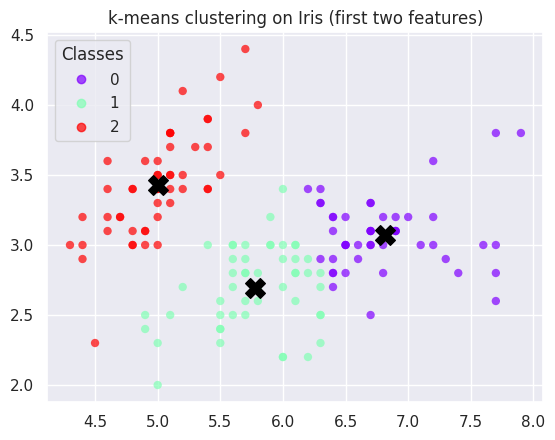

In [97]:
plt.figure()
plot_iris(legend=True, classes=classes)   # use k-means cluster assignments
plt.scatter(mus[:, 0], mus[:, 1], marker='X', s=200, c='black')  # mark centers
plt.title("k-means clustering on Iris (first two features)")
plt.show()

### Optional Exercise: Plot the progression of cluster means

Modify your K-means implementation so that after each iteration, you store the current means. Then, create a plot that shows how the cluster centers move step by step until convergence.

Hints:

Keep a list of means after each iteration.

Use scatter plots of the data points and plot the cluster centers (e.g. with X markers).

You may use different colors or arrows to show the trajectory of each cluster center.

In [98]:
def optimize_k_means_history(mus_0, data_x):#, on_step):
    mus_history = np.zeros((1, mus_0.shape[0], mus_0.shape[1]))
    mus_history[0] = mus_0
    while True:
        result, classes = k_means_step(mus_0, data_x)
        mus_history = np.append(mus_history, [result], axis=0)
        if(np.allclose(mus_0, result)):
                break
        mus_0 = result
    return mus_history, classes

In [99]:
k = 3
mus_0 = iris_x[:k]                 # first k points as initial centers
mus_history, classes = optimize_k_means_history(mus_0, iris_x)

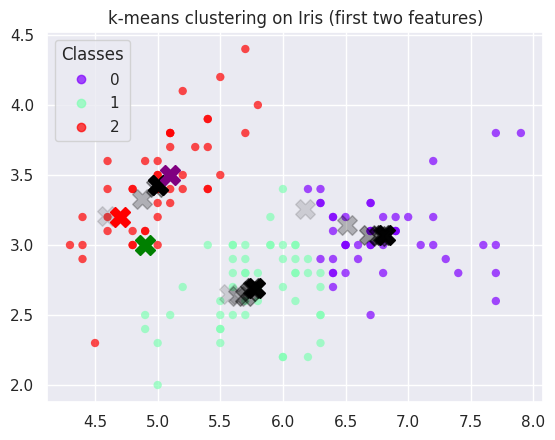

In [100]:
plt.figure()
plot_iris(legend=True, classes=classes)   # use k-means cluster assignments
N = len(mus_history)
colors = ['purple', 'green', 'red']
for k in range(3):
    plt.plot(mus_0[k, 0], mus_0[k, 1], 'X', markersize=15, c=colors[k])  # plot initial centers
for i, mus in enumerate(mus_history[0:]):
    # for k in range(3):
    #     plt.plot(mus_history[i-1, k, 0], mus_history[i-1, k, 1], 'o', markersize=8, c=colors[k], alpha=0.3)  # plot previous centers
    plt.scatter(mus[:, 0], mus[:, 1], marker='X', s=200, c='black', alpha=i/N)  # mark centers
plt.title("k-means clustering on Iris (first two features)")
plt.show()